Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una regressione sulla feature aps.

**Classificazione multiclasse su "dzgroup"**

1. Procedere allo split train-test secondo il rapporto 95%-5% in forma stratificata secondo i valori della variabile target.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(".\dataset_esercitazione.csv", sep=',')
print(df)

X = df.drop(columns=['dzgroup', 'dzclass'])
y = df['dzgroup']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05, random_state=42, stratify=y)  #train test split

print(f"Dimensioni del dataset originale: {X.shape[0]} pazienti")
print(f"Dimensioni del Training Set (95%): {X_train.shape[0]} pazienti")
print(f"Dimensioni del Test Set (5%): {X_test.shape[0]} pazienti")

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\giova\AppData\Local\Temp\ipykernel_15004\3736001930.py:4: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv(".\dataset_esercitazione.csv", sep=',')


           age     sex            dzgroup             dzclass  num.co   edu  \
0     62.84998    male        Lung Cancer              Cancer       0  11.0   
1     60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2     52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3     42.38498  female        Lung Cancer              Cancer       2  11.0   
4     79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
...        ...     ...                ...                 ...     ...   ...   
9100  66.07300    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   
9101  55.15399  female               Coma                Coma       1  11.0   
9102  70.38196    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
9103  47.01999    male       MOSF w/Malig            ARF/MOSF       1  13.0   
9104  81.53894  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   

          income  scoma  charges      totcst  ...  

2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione precedente.

In [2]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

cat_values = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num_values = X_train.select_dtypes(include=['number']).columns.tolist()

#per gestire i dati mancanti
report_missing = X_train.isnull().sum() / len(X_train) * 100
print(f"Percentuale dati mancanti:\n{report_missing}")

#contiamo le colonne con i dati mancanti
nan_columns = report_missing[report_missing > 0].index.tolist()
missing_cat = [col for col in nan_columns if col in cat_values]
missing_num = [col for col in nan_columns if col in num_values]

#imputazione per variabili numeriche e categoriche
if len(missing_num) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X_train[missing_num] = imputer_num.fit_transform(X_train[missing_num])
    X_test[missing_num] = imputer_num.transform(X_test[missing_num])
if len(missing_cat) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_train[missing_cat] = imputer_cat.fit_transform(X_train[missing_cat])
    X_test[missing_cat] = imputer_cat.transform(X_test[missing_cat])

#encoding per variabili categoriche
if len(cat_values) > 0:
    encoder_cat = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-5)
    X_train[cat_values] = encoder_cat.fit_transform(X_train[cat_values])
    X_test[cat_values] = encoder_cat.transform(X_test[cat_values])

Percentuale dati mancanti:
age          0.000000
sex          0.000000
num.co       0.000000
edu         17.944271
income      32.778356
scoma        0.011562
charges      1.884611
totcst       9.654295
totmcst     38.189386
avtisst      0.913400
race         0.474043
sps          0.011562
aps          0.011562
surv2m       0.011562
surv6m       0.011562
hday         0.000000
diabetes     0.000000
dementia     0.000000
ca           0.000000
prg2m       18.140826
prg6m       17.967395
dnr          0.335299
dnrday       0.335299
meanbp       0.011562
wblc         2.335530
hrt          0.011562
resp         0.011562
temp         0.011562
pafi        25.494277
alb         36.998497
bili        28.639149
crea         0.739970
sod          0.011562
ph          25.031796
glucose     49.520176
bun         47.959302
urine       53.451266
adlp        61.903110
adls        31.448722
adlsc        0.000000
death        0.000000
dtype: float64


3. Rimuovere le feature che presentano elevata correlazione con la variabile target e successivamente analizzare le possibili feature multicollineari rimanenti.

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()  #necessario poiché, a differenza di 'death', 'dzgroup' è una feature di stringhe, di cui dunque deve essere effettuato l'encoding
y_train_encoded = label_encoder.fit_transform(y_train)
df_train = X_train.copy()
df_train['dzgroup'] = y_train_encoded

corr_target = df_train.corr()['dzgroup'].drop('dzgroup').abs().sort_values(ascending=False)
print(corr_target)

corr_matrix = df_train.corr().abs()
#print(corr_matrix)

#analisi multicollinearità
rel_threshold = 0.7
corr_pairs = corr_matrix.unstack().sort_values().drop_duplicates()
corr_pairs = corr_pairs[corr_pairs != 1.0]
rel_features = corr_pairs[corr_pairs > rel_threshold]
print(rel_features.sort_values(ascending=False))

var_to_remove = ['charges', 'surv2m', 'prg2m', 'sps', 'adlsc']
X_train = X_train.drop(columns=var_to_remove)
X_test = X_test.drop(columns=var_to_remove)
print(f"Feature rimanenti: {X_train.shape[1]}")

surv6m      0.380406
ca          0.351756
surv2m      0.269921
death       0.268349
prg6m       0.244058
dnrday      0.223326
totcst      0.186698
avtisst     0.185656
charges     0.183353
aps         0.158021
totmcst     0.153295
dnr         0.134615
diabetes    0.134073
prg2m       0.129373
scoma       0.088372
sps         0.084959
edu         0.077847
crea        0.077838
num.co      0.072687
dementia    0.066399
income      0.061435
hday        0.057574
wblc        0.046468
age         0.040151
bili        0.038632
meanbp      0.034107
temp        0.028945
alb         0.028211
sod         0.025018
race        0.022664
adls        0.021225
bun         0.018443
pafi        0.018426
resp        0.013735
adlsc       0.013721
adlp        0.013616
glucose     0.013317
hrt         0.011219
sex         0.008589
urine       0.003092
ph          0.000269
Name: dzgroup, dtype: float64
surv6m  surv2m     0.960185
prg6m   prg2m      0.890141
adls    adlsc      0.880830
aps     sps        0.7958

4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per la regressione con i seguenti iperparametri(*)
    a. Classificatore
        i. criterion: “gini”, “log_loss”
        ii. min_samples_split: 2, 5, 10
        iii. max_features: “sqrt”, 5
    b. Regressore
        i. criterion: “squared_error”, “absolute_error”
        ii. min_samples_split: 2, 5, 10
        iii. max_features: “sqrt”, 5

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

iperparam_grid = {
    'criterion': ["gini", "log_loss"],
    'min_samples_split': [2, 5, 10],
    'max_features': ["sqrt", 5]
}

clf = RandomForestClassifier(random_state=42)  #modello base
grid_search_clf = GridSearchCV(
    estimator=clf,
    param_grid=iperparam_grid,
    cv=5,  #cross-validation a 5 fold
    scoring='accuracy',
    n_jobs=-1
)

grid_search_clf.fit(X_train, y_train)
print(f"Search Grid - Migliori iperparametri: {grid_search_clf.best_params_}, Migliore accuratezza: {grid_search_clf.best_score_:.4f}")

Search Grid - Migliori iperparametri: {'criterion': 'log_loss', 'max_features': 'sqrt', 'min_samples_split': 10}, Migliore accuratezza: 0.7143


5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni classe, ciascuna valutata in modalità one-vs-rest.

PERFORMANCE SUL TEST SET - Accuracy: 0.7346, ROC-AUC Score (Macro OvR): 0.9452

Report di Classificazione dettagliato:
                   precision    recall  f1-score   support

ARF/MOSF w/Sepsis       0.71      0.90      0.80       176
              CHF       0.64      0.70      0.67        69
             COPD       0.71      0.31      0.43        48
        Cirrhosis       1.00      0.48      0.65        25
     Colon Cancer       0.89      0.62      0.73        26
             Coma       0.75      0.60      0.67        30
      Lung Cancer       0.80      0.96      0.87        46
     MOSF w/Malig       0.82      0.64      0.72        36

         accuracy                           0.73       456
        macro avg       0.79      0.65      0.69       456
     weighted avg       0.75      0.73      0.72       456



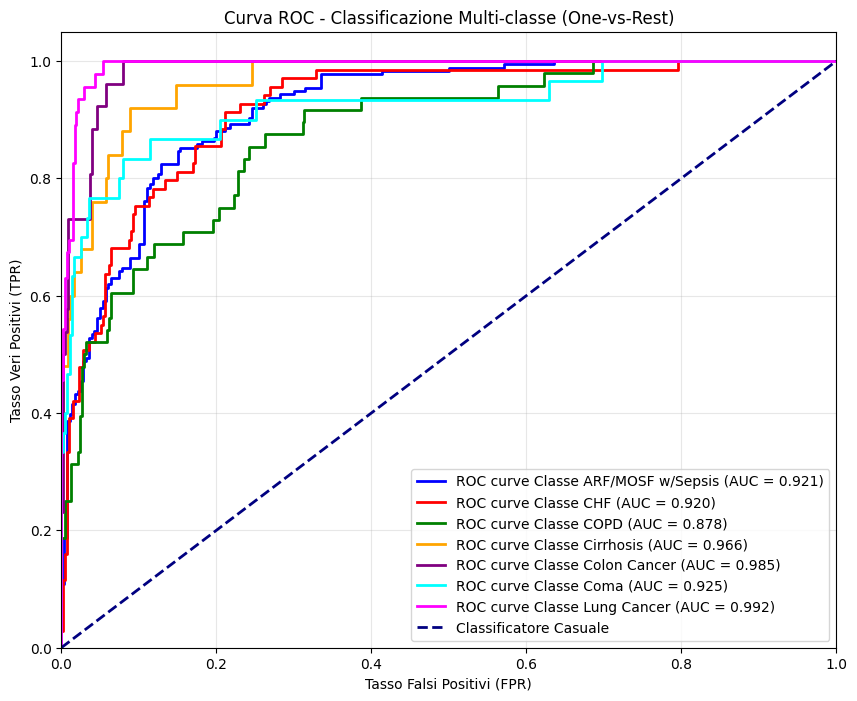

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

best_clf = grid_search_clf.best_estimator_  #miglior estimatore

classes = np.unique(y_test)  #classi uniche nel target
n_classes = len(classes)

#previsioni e probabilità previste per TUTTE le classi
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test) #restituisce una matrice (n_campioni, n_classi)

#binarizziamo le label reali per calcolare la ROC per singola classe
y_te_binarized = label_binarize(y_test, classes=classes)

accuracy = accuracy_score(y_test, y_pred)  #metriche globali
roc_auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')  #per l'AUC multi-classe usiamo l'approccio One-vs-Rest (ovr) e una media macro

print(f"PERFORMANCE SUL TEST SET - Accuracy: {accuracy:.4f}, ROC-AUC Score (Macro OvR): {roc_auc_macro:.4f}")
print("\nReport di Classificazione dettagliato:")
print(classification_report(y_test, y_pred))

#calcoliamo i tassi FPR, TPR e AUC per ogni singola classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_te_binarized[:, i], y_prob[:, i])  #calcola la curva per l'i-esima classe
    roc_auc[i] = auc(fpr[i], tpr[i])

#plot
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta']  #palette di colori

for i, color in zip(range(n_classes), colors):  #plotta la curva ROC per ogni classe
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve Classe {classes[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificatore Casuale')  #classificatore casuale

#formattazione del grafico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso Falsi Positivi (FPR)')
plt.ylabel('Tasso Veri Positivi (TPR)')
plt.title('Curva ROC - Classificazione Multi-classe (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()